<div style="padding: 28px 32px; border: 1px solid #bfdbfe; border-left: 8px solid #2563eb; border-radius: 12px; background: linear-gradient(135deg, #eff6ff 0%, #f8fafc 100%);">

<h1 style="margin: 0; color: #1e3a8a;">Machine Learning Zoomcamp 2026</h1>
<p style="margin: 8px 0 18px; font-size: 1.2em; color: #334155;"><strong>Homework 2</strong> · Regression</p>

| Student | Cohort | Dataset | Environment |
| :--- | :--- | :--- | :--- |
| Carlos Ibarra | 2026 | 2026 Car Fuel Efficiency | Python 3.11+ · Pandas · NumPy |

</div>

### Learning path

| Step | Focus |
| :---: | :--- |
| 01 | Initial setup and data loading |
| 02 | Exploratory data analysis |
| 03 | Baseline model functions |
| 04 | Missing-value imputation |
| 05 | Ridge regularization |
| 06 | Model stability across random seeds |
| 07 | Final test evaluation |

In [41]:
# Import NumPy for numerical operations.
import numpy as np
# Import Pandas for tabular data manipulation.
import pandas as pd
# Import Matplotlib for creating visualizations.
import matplotlib.pyplot as plt
# Import Seaborn for statistical visualizations.
import seaborn as sns

# Apply Seaborn's white-grid style to all plots.
sns.set_theme(style="whitegrid")

# Define the relative path to the dataset file.
data_path = "data/car_fuel_efficiency_2026.csv"
# Load the CSV file into a Pandas DataFrame.
df = pd.read_csv(data_path)

# Define the five columns used in the regression analysis.
selected_columns = [
    "engine_displacement",  # Store engine size as a predictor.
    "horsepower",  # Store engine power as a predictor.
    "vehicle_weight",  # Store vehicle weight as a predictor.
    "model_year",  # Store model year as a predictor.
    "fuel_efficiency_mpg",  # Store fuel efficiency as the target.
]
# Keep only the selected columns and make an independent copy.
df = df[selected_columns].copy()

# Print the number of rows and columns in the filtered DataFrame.
print(f"Shape: {df.shape}")
# Display the first five rows of the filtered DataFrame.
df.head()

Shape: (10000, 5)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Step 2 · Initial EDA

**Objective.** Inspect the target distribution and establish the data-quality facts needed for the regression workflow.

</div>

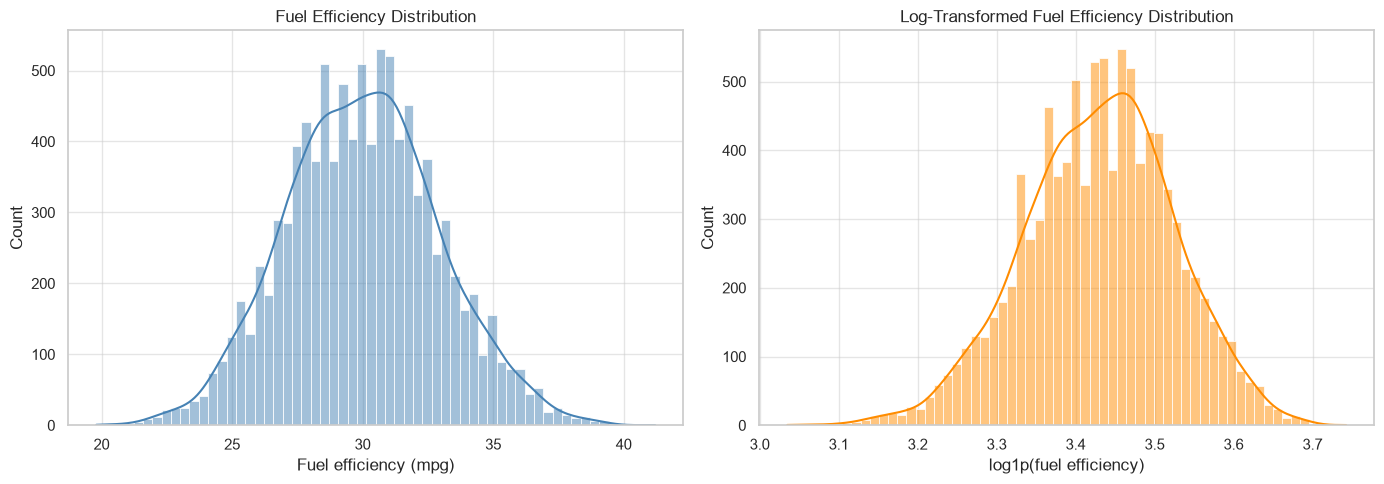

Target skewness: 0.081
Conclusion: the target is approximately symmetric; log transformation is not necessary.


In [21]:
# Select the target variable from the filtered DataFrame.
target = df["fuel_efficiency_mpg"]
# Calculate the target's skewness to quantify distribution asymmetry.
target_skewness = target.skew()

# Create two side-by-side axes for the original and transformed distributions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the original target distribution with a kernel density estimate.
# Kernel Density Estimation (KDE) provides a smooth estimate of the distribution's density.
sns.histplot(target, kde=True, ax=axes[0], color="steelblue")
# Set the title of the original-distribution plot.
axes[0].set_title("Fuel Efficiency Distribution")
# Label the x-axis of the original-distribution plot.
axes[0].set_xlabel("Fuel efficiency (mpg)")

# Plot the log-transformed target distribution with a kernel density estimate.
sns.histplot(np.log1p(target), kde=True, ax=axes[1], color="darkorange")
# Set the title of the log-transformed distribution plot.
axes[1].set_title("Log-Transformed Fuel Efficiency Distribution")
# Label the x-axis of the log-transformed distribution plot.
axes[1].set_xlabel("log1p(fuel efficiency)")

# Adjust the spacing between plots to prevent overlapping labels.
plt.tight_layout()
# Render both plots in the notebook output.
plt.show()

# Print the skewness rounded to three decimal places.
print(f"Target skewness: {target_skewness:.3f}")
# Check whether the target is close enough to symmetric to avoid transformation.
if abs(target_skewness) < 0.5:
    # Report that a log transformation is unnecessary for an approximately symmetric target.
    print("Conclusion: the target is approximately symmetric; log transformation is not necessary.")
# Handle the case where the target distribution is materially skewed.
else:
    # Recommend considering a log transformation for a skewed target.
    print("Conclusion: the target is skewed; consider a log transformation.")

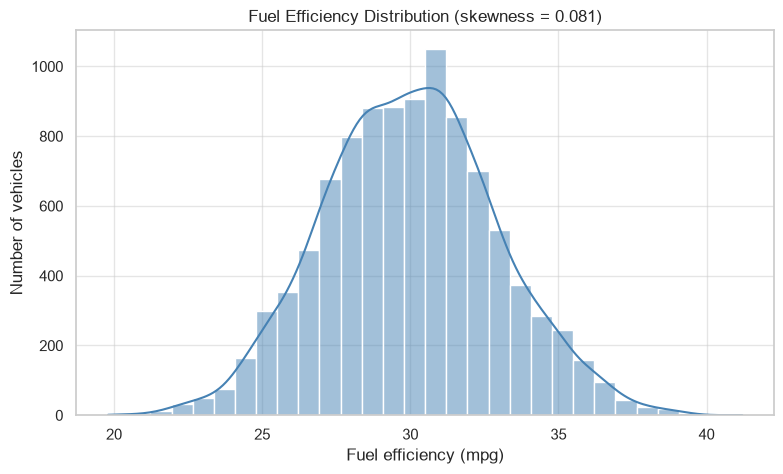

In [22]:
# Select the target variable so this visualization cell can run independently.
target = df["fuel_efficiency_mpg"]
# Calculate the skewness value to display in the plot title.
target_skewness = target.skew()

# Create a figure for the target distribution.
plt.figure(figsize=(9, 5))
# Plot the target histogram and its kernel density estimate.
sns.histplot(target, bins=30, kde=True, color="steelblue")
# Add the skewness value to the plot title.
plt.title(f"Fuel Efficiency Distribution (skewness = {target_skewness:.3f})")
# Label the x-axis with the target unit.
plt.xlabel("Fuel efficiency (mpg)")
# Label the y-axis with the number of vehicles per bin.
plt.ylabel("Number of vehicles")
# Display the target-distribution plot.
plt.show()

<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Target distribution**
`fuel_efficiency_mpg` has skewness **`0.081`**, so its distribution is approximately symmetric. A `log1p` transformation is not necessary for this target.

</div>

<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Q1 · Missing values

**Question.** Which selected feature has missing values, and how many are there?

</div>

In [14]:
# Count missing values in every selected feature while excluding the target.
missing_values = df.drop(columns="fuel_efficiency_mpg").isna().sum()
# Keep and sort only the features that have at least one missing value.
missing_features = missing_values[missing_values > 0].sort_values(ascending=False)

# Check whether any selected feature contains missing values.
if missing_features.empty:
    # Report that no selected feature has missing values.
    print("No selected features have missing values.")
# Handle the case where one or more selected features contain missing values.
else:
    # Introduce the missing-value summary.
    print("Features with missing values:")
    # Display the feature names and their counts of missing values.
    print(missing_features.to_frame(name="missing_values"))

Features with missing values:
            missing_values
horsepower             877


<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Q1**
Only **`horsepower`** has missing values among the selected features: **`877`** records.

</div>

<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Q2 · Horsepower median

**Question.** What is the median (50th percentile) of `horsepower`?

</div>

In [15]:
# Calculate the 50th percentile of the horsepower feature, ignoring missing values.
horsepower_median = df["horsepower"].median()
# Print the horsepower median with one decimal place.
print(f"Median horsepower (50th percentile): {horsepower_median:.1f}")

Median horsepower (50th percentile): 254.0


<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Q2**
The median (50th percentile) of `horsepower` is **`254.0`**.

</div>

<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Step 3 · Baseline Model Functions

**Objective.** Define reusable NumPy utilities for reproducible splitting, ordinary least squares training, and RMSE evaluation.

</div>

In [42]:
# Define a reproducible 60/20/20 train, validation, and test split.
def split_dataset(df, seed=42):
    # Store the number of rows in the input DataFrame.
    n = len(df)
    # Calculate the validation-set size as 20% of the data.
    n_val = int(n * 0.2)
    # Calculate the test-set size as 20% of the data.
    n_test = int(n * 0.2)
    # Assign all remaining rows to the training set.
    n_train = n - n_val - n_test

    # Set NumPy's random seed for reproducible shuffling.
    np.random.seed(seed)
    # Create an array containing every row position.
    idx = np.arange(n)
    # Shuffle the row positions in place.
    np.random.shuffle(idx)

    # Select the shuffled rows assigned to training.
    df_train = df.iloc[idx[:n_train]].copy()
    # Select the shuffled rows assigned to validation.
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    # Select the remaining shuffled rows assigned to testing.
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    # Return the three independent DataFrame splits.
    return df_train, df_val, df_test


# Define the root mean squared error evaluation metric.
def rmse(y, y_pred):
    # Calculate each prediction residual.
    error = y_pred - y
    # Calculate the mean squared error across all residuals.
    mse = (error ** 2).mean()
    # Return the square root of the mean squared error.
    return np.sqrt(mse)


# Define ordinary least squares training with the analytical normal equation.
def train_linear_regression(X, y):
    # Add a column of ones to represent the intercept term.
    X_full = np.column_stack([np.ones(X.shape[0]), X])
    # Compute X-transpose times X.
    XTX = X_full.T.dot(X_full)
    # Compute the inverse of X-transpose times X.
    XTX_inv = np.linalg.inv(XTX)
    # Calculate the full weight vector using the normal equation.
    w_full = XTX_inv.dot(X_full.T).dot(y)
    # Extract the intercept from the full weight vector.
    w0 = w_full[0]
    # Extract the feature coefficients from the full weight vector.
    w = w_full[1:]

    # Return the intercept and feature coefficients separately.
    return w0, w


# Split the filtered dataset using the required seed.
df_train, df_val, df_test = split_dataset(df, seed=42)

# Extract the target values from the training split.
y_train = df_train["fuel_efficiency_mpg"].values
# Extract the target values from the validation split.
y_val = df_val["fuel_efficiency_mpg"].values
# Extract the target values from the test split.
y_test = df_test["fuel_efficiency_mpg"].values

# Print the number of rows assigned to the training split.
print(f"Train rows: {len(df_train)}")
# Print the number of rows assigned to the validation split.
print(f"Validation rows: {len(df_val)}")
# Print the number of rows assigned to the test split.
print(f"Test rows: {len(df_test)}")

Train rows: 6000
Validation rows: 2000
Test rows: 2000


<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Q3 · Missing-value imputation

**Question.** Does zero imputation or training-mean imputation produce the lower validation RMSE?

</div>

In [43]:
# Define the predictor columns used by the regression model.
features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]

# Prepare a numerical feature matrix after filling missing feature values.
def prepare_X(df, fill_value):
    # Select only the predictor columns and create an independent copy.
    df_num = df[features].copy()
    # Replace missing feature values with the supplied value.
    df_num = df_num.fillna(fill_value)
    # Convert the prepared feature DataFrame into a NumPy matrix.
    X = df_num.values

    # Return the prepared feature matrix.
    return X


# Prepare the training features by filling missing values with zero.
X_train_zero = prepare_X(df_train, fill_value=0)
# Prepare the validation features by filling missing values with zero.
X_val_zero = prepare_X(df_val, fill_value=0)
# Train the zero-imputation linear regression model.
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)
# Generate validation predictions from the zero-imputation model.
y_pred_zero = w0_zero + X_val_zero.dot(w_zero)
# Calculate the validation RMSE for zero imputation.
rmse_zero = rmse(y_val, y_pred_zero)

# Calculate the mean horsepower using only the training split.
horsepower_mean = df_train["horsepower"].mean()
# Prepare the training features by filling missing values with the training mean.
X_train_mean = prepare_X(df_train, fill_value=horsepower_mean)
# Prepare the validation features by filling missing values with the training mean.
X_val_mean = prepare_X(df_val, fill_value=horsepower_mean)
# Train the mean-imputation linear regression model.
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
# Generate validation predictions from the mean-imputation model.
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
# Calculate the validation RMSE for mean imputation.
rmse_mean = rmse(y_val, y_pred_mean)

# Build a table that compares the rounded validation RMSE values.
rmse_comparison = pd.DataFrame(
    {
        "Imputation": ["Zero", "Training mean"],
        "Validation RMSE": [round(rmse_zero, 3), round(rmse_mean, 3)],
    }
)
# Print a label for the comparison table.
print("Validation RMSE comparison:")
# Print the comparison table without its DataFrame index.
print(rmse_comparison.to_string(index=False))

Validation RMSE comparison:
   Imputation  Validation RMSE
         Zero            2.205
Training mean            2.202


<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Q3**
Training-mean imputation achieves the lower validation RMSE: **`2.202`**, compared with **`2.205`** for zero imputation.

</div>

<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Q4 · Regularized linear regression

**Question.** Which Ridge regularization value `r` produces the lowest validation RMSE with zero imputation?

</div>

In [44]:
# Define Ridge linear regression using the analytical normal equation.
def train_linear_regression_reg(X, y, r=0.0):
    # Add a column of ones to represent the intercept term.
    X_full = np.column_stack([np.ones(X.shape[0]), X])
    # Compute X-transpose times X.
    XTX = X_full.T.dot(X_full)
    # Create the Ridge regularization matrix scaled by r.
    reg = r * np.eye(XTX.shape[0])
    # Add the Ridge penalty to X-transpose times X.
    XTX = XTX + reg
    # Compute the inverse of the regularized matrix.
    XTX_inv = np.linalg.inv(XTX)
    # Calculate the full weight vector using the Ridge normal equation.
    w_full = XTX_inv.dot(X_full.T).dot(y)
    # Extract the intercept from the full weight vector.
    w0 = w_full[0]
    # Extract the feature coefficients from the full weight vector.
    w = w_full[1:]

    # Return the intercept and feature coefficients separately.
    return w0, w


# Prepare the training features by filling missing values with zero.
X_train_ridge = prepare_X(df_train, fill_value=0)
# Prepare the validation features by filling missing values with zero.
X_val_ridge = prepare_X(df_val, fill_value=0)
# Define the regularization values required by the homework.
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
# Create a list to keep each raw validation RMSE.
ridge_scores = []

# Train and evaluate one Ridge model for every regularization value.
for r in r_values:
    # Train a Ridge model with the current regularization value.
    w0_ridge, w_ridge = train_linear_regression_reg(X_train_ridge, y_train, r=r)
    # Generate validation predictions with the current Ridge model.
    y_pred_ridge = w0_ridge + X_val_ridge.dot(w_ridge)
    # Calculate the validation RMSE for the current Ridge model.
    score = rmse(y_val, y_pred_ridge)
    # Store the current regularization value and its unrounded RMSE.
    ridge_scores.append((r, score))

# Build a table with RMSE values rounded to four decimal places.
ridge_comparison = pd.DataFrame(
    [(r, round(score, 4)) for r, score in ridge_scores],
    columns=["r", "Validation RMSE"],
)
# Select the lowest raw RMSE and use the smallest r to break exact ties.
best_r, best_score = min(ridge_scores, key=lambda pair: (pair[1], pair[0]))

# Print a label for the Ridge comparison table.
print("Ridge validation RMSE comparison:")
# Print the rounded validation RMSE for every regularization value.
print(ridge_comparison.to_string(index=False))
# Print the best regularization value and its rounded validation RMSE.
print(f"Best r: {best_r} (validation RMSE: {best_score:.4f})")

Ridge validation RMSE comparison:
     r  Validation RMSE
  0.00           2.2053
  0.01           2.2058
  0.10           2.2241
  1.00           2.3492
  5.00           2.4094
 10.00           2.4195
100.00           2.4292
Best r: 0 (validation RMSE: 2.2053)


<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Q4**
The lowest validation RMSE is **`2.2053`** at **`r = 0`**. Ridge regularization did not improve this validation result.

</div>

<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Q5 · Model stability across random seeds

**Question.** How much does validation RMSE vary across ten reproducible data splits?

</div>

In [40]:
# Define the random seeds required for the stability evaluation.
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# Create a list to store each seed and its validation RMSE.
seed_scores = []

# Train and evaluate the unregularized model for every random seed.
for seed in seeds:
    # Create reproducible train, validation, and test splits for the current seed.
    df_train_seed, df_val_seed, df_test_seed = split_dataset(df, seed=seed)
    # Prepare training features by filling missing values with zero.
    X_train_seed = prepare_X(df_train_seed, fill_value=0)
    # Prepare validation features by filling missing values with zero.
    X_val_seed = prepare_X(df_val_seed, fill_value=0)
    # Extract the training target values.
    y_train_seed = df_train_seed["fuel_efficiency_mpg"].values
    # Extract the validation target values.
    y_val_seed = df_val_seed["fuel_efficiency_mpg"].values
    # Train unregularized linear regression for the current split.
    w0_seed, w_seed = train_linear_regression(X_train_seed, y_train_seed)
    # Generate validation predictions for the current split.
    y_pred_seed = w0_seed + X_val_seed.dot(w_seed)
    # Calculate the validation RMSE for the current split.
    score = rmse(y_val_seed, y_pred_seed)
    # Store the current seed and its unrounded validation RMSE.
    seed_scores.append((seed, score))

# Build a table showing the validation RMSE for each random seed.
seed_comparison = pd.DataFrame(
    [(seed, round(score, 4)) for seed, score in seed_scores],
    columns=["Seed", "Validation RMSE"],
)
# Extract the raw RMSE values for the stability calculation.
scores = [score for _, score in seed_scores]
# Calculate the standard deviation across all validation RMSE values.
rmse_std = np.std(scores)
# Round the RMSE standard deviation to three decimal places.
rmse_std_rounded = round(rmse_std, 3)

# Print a label for the per-seed validation results.
print("Validation RMSE by random seed:")
# Print the validation RMSE table without its DataFrame index.
print(seed_comparison.to_string(index=False))
# Print the rounded standard deviation of validation RMSE.
print(f"Validation RMSE standard deviation: {rmse_std_rounded:.3f}")

Validation RMSE by random seed:
 Seed  Validation RMSE
    0           2.2392
    1           2.2021
    2           2.1634
    3           2.2044
    4           2.2019
    5           2.2458
    6           2.2697
    7           2.1908
    8           2.2166
    9           2.2070
Validation RMSE standard deviation: 0.029


<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Q5**
The validation RMSE standard deviation across seeds 0–9 is **`0.029`**, indicating limited variation across the tested splits.

</div>

<div style="padding: 18px 22px; border-left: 6px solid #2563eb; border-radius: 8px; background: #eff6ff;">

## Q6 · Final model evaluation on test data

**Question.** What test RMSE does the final Ridge model achieve after training on the combined train and validation data?

</div>

In [45]:
# Create the required train, validation, and test splits with seed 9.
df_train, df_val, df_test = split_dataset(df, seed=9)
# Combine the training and validation splits into one 80% training DataFrame.
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

# Extract the target values from the combined training DataFrame.
y_full_train = df_full_train["fuel_efficiency_mpg"].values
# Extract the target values from the unseen test DataFrame.
y_test = df_test["fuel_efficiency_mpg"].values

# Prepare the combined training features by filling missing values with zero.
X_full_train = prepare_X(df_full_train, fill_value=0)
# Prepare the test features by filling missing values with zero.
X_test = prepare_X(df_test, fill_value=0)

# Define the Ridge regularization value required for the final model.
final_r = 0.001
# Train the final Ridge model using all available training data.
w0_final, w_final = train_linear_regression_reg(X_full_train, y_full_train, r=final_r)
# Generate predictions for the unseen test set.
y_pred_test = w0_final + X_test.dot(w_final)
# Calculate the unrounded test RMSE.
test_rmse = rmse(y_test, y_pred_test)
# Round the test RMSE to three decimal places.
test_rmse_rounded = round(test_rmse, 3)

# Print the final test RMSE.
print(f"Test RMSE: {test_rmse_rounded:.3f}")

Test RMSE: 2.236


<div style="padding: 14px 18px; border-left: 5px solid #16a34a; border-radius: 8px; background: #f0fdf4;">

**Result · Q6**
The final Ridge model, trained on the combined train and validation data, achieves a test RMSE of **`2.236`**.

</div>

<div style="padding: 22px 26px; border: 1px solid #bfdbfe; border-top: 7px solid #2563eb; border-radius: 12px; background: #f8fafc;">

## Homework 2 · Results dashboard

| Question | Focus | Final answer |
| :---: | :--- | :--- |
| **Q1** | Missing values | `horsepower`: **`877`** |
| **Q2** | Horsepower median | **`254.0`** |
| **Q3** | Best imputation | **Training mean** (`2.202` RMSE) |
| **Q4** | Best Ridge parameter | **`r = 0`** (`2.2053` RMSE) |
| **Q5** | RMSE stability | **`0.029`** standard deviation |
| **Q6** | Final test performance | **`2.236`** RMSE |

</div>

<div style="margin-top: 16px; padding: 16px 20px; border-left: 5px solid #f59e0b; border-radius: 8px; background: #fffbeb;">

### Key takeaway

The training-mean imputation strategy slightly improved validation RMSE, while additional Ridge regularization did not improve the selected model. The final model achieved a test RMSE of **`2.236`**, and the seed analysis showed stable validation performance across the tested splits.

</div>